# **Libraries**

In [14]:
from mpl_toolkits.basemap import Basemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, BoundaryNorm
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr
from datetime import datetime 
import re
from matplotlib.transforms import Bbox
import matplotlib.ticker as mticker
import os
import glob
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib import lines
from matplotlib.patches import FancyArrowPatch

# **Function to create the map**

In [15]:
def plot_map_with_contour(coord_df, netcdf_file, contour_var, min_var, max_var, n_levels, cmap,
             llcrnrlon, llcrnrlat, urcrnrlon, urcrnrlat, 
             parallels, display_parralel_labels, meridians, display_meridians_labels, 
             police_size, cbar_label, loc, bbox_to_anchor, figsize, figsize_limit, filename = None, log_colorbar=True, display_cbar=True):
    """
    Function to create a map with station positions and a background contour plot from a NetCDF file.
    
    Parameters:
        coord_df (pd.DataFrame): Dataframe containing station coordinates with 'Station', 'Longitude', and 'Latitude' columns.
        netcdf_file (str): Path to the NetCDF file.
        contour_var (str): Variable name from the NetCDF file to use for the background contour plot.
        min_var (float): Minimum value for the color bar.
        max_var (float): Maximum value for the color bar.
        n_levels (int): Number of contour levels.
        cmap (str): Colormap to use for the contour plot.
        llcrnrlon (float): Lower left longitude.
        llcrnrlat (float): Lower left latitude.
        urcrnrlon (float): Upper right longitude.
        urcrnrlat (float): Upper right latitude.
        parallels (list): List of parallel lines to draw.
        display_parralel_labels (list): List of booleans indicating where to display parallel labels.
        meridians (list): List of meridian lines to draw.
        display_meridians_labels (list): List of booleans indicating where to display meridian labels.
        police_size (float): Font size for labels and colorbar.
        cbar_label (str): Label for the color bar.
        loc (str): Location of the legend.
        bbox_to_anchor (tuple): Position of the legend.
        figsize (tuple) : figure size 
        filename (str): Path to save the map at png format 
        log_colorbar (bool, optional): Whether to use a logarithmic color scale. Default is True.
        display_cbar (bool, optional): Whether to display the color bar. Default is True.
    """
    
    # Load NetCDF data
    ds = netcdf_file
    variable = ds[contour_var][0, :, :]

    # Create the grid for mapping
    lon, lat = np.meshgrid(ds.longitude, ds.latitude)

    # Set normalization (log or linear)
    norm = mcolors.LogNorm(vmin=min_var, vmax=max_var) if log_colorbar else mcolors.Normalize(vmin=min_var, vmax=max_var)

    # Define tick positions for colorbar
    cbar_ticks = np.logspace(np.log10(min_var), np.log10(max_var), num=6) if log_colorbar else np.linspace(min_var, max_var, num=6)

    # Adjust map boundaries to maintain aspect ratio (longitude range = latitude range)
    lon_range = abs(urcrnrlon - llcrnrlon)
    lat_range = abs(urcrnrlat - llcrnrlat)
    max_range = max(lon_range, lat_range)  # Ensure the map is not cropped
    
    lon_center = (llcrnrlon + urcrnrlon) / 2
    lat_center = (llcrnrlat + urcrnrlat) / 2
    
    llcrnrlon = lon_center - max_range / 2
    urcrnrlon = lon_center + max_range / 2
    llcrnrlat = lat_center - max_range / 2
    urcrnrlat = lat_center + max_range / 2
    
    new_lon_range = abs(urcrnrlon - llcrnrlon)
    new_lat_range = abs(urcrnrlat - llcrnrlat)
    print(new_lon_range, new_lat_range, 'ratio: ', new_lon_range/new_lat_range)
    # Create figure and map
    fig, ax = plt.subplots(figsize=figsize)
    
    fig_width, fig_height = fig.get_size_inches()
    print(f"Figure width: {fig_width} inches")
    print(f"Figure height: {fig_height} inches")
    
    m = Basemap(llcrnrlon=llcrnrlon, llcrnrlat=llcrnrlat, urcrnrlon=urcrnrlon, urcrnrlat=urcrnrlat,
                resolution='f', projection='cass', lon_0 = lon_center, lat_0 = lat_center)

    # Plot background variable as contour
    x, y = m(lon, lat)
    contour = m.contourf(x, y, variable, levels=np.logspace(np.log10(min_var), np.log10(max_var), n_levels) if log_colorbar else np.linspace(min_var, max_var, n_levels), 
                          cmap=cmap, norm=norm)
    
    # Add colorbar if required
    if display_cbar:
        cbar = m.colorbar(contour, location='right', pad="5%")
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels([f"{tick:.2f}" for tick in cbar_ticks])
        cbar.set_label(cbar_label, size=police_size)
        cbar.ax.tick_params(labelsize=police_size)

    # Create a marker map for stations
    markers = ['o', 's', '^', 'D', 'p']
    unique_station = coord_df['Station'].unique()
    marker_map = {station: markers[i % len(markers)] for i, station in enumerate(unique_station)}

    # Plot stations
    for station in unique_station:
        subset = coord_df[coord_df['Station'] == station]
        lons, lats = subset['Longitude'].values, subset['Latitude'].values
        x, y = m(lons, lats)
        m.scatter(x, y, 300, marker=marker_map[station], label=station, c='#777880', 
                  edgecolors='white', linewidths=2)
    
    # Draw coastlines and land
    m.drawcoastlines(linewidth=1.5)
    m.fillcontinents(color='grey', lake_color='lightblue')
    
    # Draw parallels and meridians
    m.drawparallels(parallels, labels=display_parralel_labels, fontsize=police_size)
    m.drawmeridians(meridians, labels=display_meridians_labels, fontsize=police_size)

    # Add legend
    legend = plt.legend(loc=loc, bbox_to_anchor=bbox_to_anchor, fontsize=police_size, ncol=5, borderpad=1.3)
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_facecolor('white')

    '''
    # Set the line width for all spines
    for spine in ax.spines.values():
        spine.set_linewidth(4)
    '''
    
    # Save if filename is provided 
    if filename:
        plt.savefig(filename, dpi = 300, bbox_inches='tight')
        
    # Show the map    
    plt.show()

# **Import surfacing position for APERO**

In [16]:
TZEX_positions_APERO = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/TZEX_coordinates_positions/TZEX_coordinates_APERO.csv', delimiter = '\t')
TZEX_positions_APERO['Latitude'] = TZEX_positions_APERO['Latitude']/100
TZEX_positions_APERO['Longitude'] = TZEX_positions_APERO['Longitude']/100
TZEX_positions_APERO.rename(columns={'Pattern': 'Station'}, inplace=True)

# Dictionary to map old values to new values
value_map = {
    'ST01': 'PSS1',
    'ST11': 'PSS2',
    'ST25': 'PSS3',
    'ST32': 'PSS4',
    'ST42': 'PSS5'
}

# Replace the values in the 'Station' column
TZEX_positions_APERO['Station'] = TZEX_positions_APERO['Station'].map(value_map)
TZEX_positions_APERO['Cruise'] = 'APERO'
TZEX_positions_APERO

,Station,Date,Time,Latitude,Longitude,Cruise
0,PSS1,10/06/2023,08:03:28,48.267559,-22.301589,APERO
1,PSS1,10/06/2023,12:31:04,48.279144,-22.288439,APERO
2,PSS1,10/06/2023,17:05:28,48.286367,-22.273916,APERO
3,PSS1,13/06/2023,12:50:53,48.269805,-22.069657,APERO
4,PSS2,16/06/2023,08:19:03,50.376893,-19.072842,APERO
5,PSS2,16/06/2023,12:26:57,50.387213,-19.062267,APERO
6,PSS2,16/06/2023,17:09:03,50.403009,-19.045865,APERO
7,PSS2,19/06/2023,08:58:21,50.549735,-19.020941,APERO
8,PSS2,19/06/2023,14:49:06,50.574451,-19.029418,APERO
9,PSS3,23/06/2023,09:14:28,47.520393,-15.521861,APERO


In [17]:
mean_positions = TZEX_positions_APERO.groupby('Station')[['Latitude', 'Longitude']].mean()

print(mean_positions)

          Latitude  Longitude
Station                      
PSS1     48.275719 -22.233400
PSS2     50.458260 -19.046267
PSS3     47.497340 -15.458429
PSS4     51.213792 -18.501299
PSS5     51.934493 -18.748380


# **Import surfacing position for VLFR**

In [18]:
TZEX_positions_vlfr = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/TZEX_coordinates_positions/TZEX_coordinates_VLFR.csv', delimiter = ';')

TZEX_positions_vlfr['Latitude'] = TZEX_positions_vlfr['Latitude']/100
TZEX_positions_vlfr['Longitude'] = TZEX_positions_vlfr['Longitude']/100
TZEX_positions_vlfr = TZEX_positions_vlfr.sort_values(by='Station', ascending=True)
TZEX_positions_vlfr['Cruise'] = 'VLFR'
TZEX_positions_vlfr = TZEX_positions_vlfr[TZEX_positions_vlfr['Station'] != 'ST03']
TZEX_positions_vlfr

,Latitude,Longitude,Station,Cruise
0,43.261439,7.308487,ST01,VLFR
1,43.260452,7.307766,ST01,VLFR
2,43.259518,7.306989,ST01,VLFR
3,43.258522,7.306081,ST01,VLFR
18,43.167097,7.135024,ST02,VLFR
17,43.168002,7.135827,ST02,VLFR
16,43.168916,7.136512,ST02,VLFR
15,43.173437,7.139526,ST02,VLFR
14,43.174157,7.139926,ST02,VLFR
13,43.174687,7.140302,ST02,VLFR


In [19]:
mean_positions = TZEX_positions_vlfr.groupby('Station')[['Latitude', 'Longitude']].mean()

print(mean_positions)

          Latitude  Longitude
Station                      
ST01     43.259983   7.307330
ST02     43.169741   7.136785


# **Import surfacing position for MBARI**

In [20]:
TZEX_positions_MBARI = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/TZEX_coordinates_positions/TZEX_coordinates_MBARI.csv', delimiter = ';')
TZEX_positions_MBARI = TZEX_positions_MBARI[TZEX_positions_MBARI['Station'] != 'Deep']
TZEX_positions_MBARI['Station'] = 'ST01'
TZEX_positions_MBARI['Cruise'] = 'MBARI'
TZEX_positions_MBARI

,Station,Date,Time,Latitude,Longitude,Cruise
1,ST01,21/11/2024,23:50:05,36.73565,-122.062237,MBARI


# **Import monthly chlorophyll-a for the APERO zone**

In [21]:
ds_APERO = xr.open_dataset('/home/aaccardo/these_alex/Analysis/APERO/Satellite/Data/NCDF/CHL/APERO/APERO_all/cmems_obs-oc_atl_bgc-plankton_my_l4-multi-1km_P1M_CHL_33.99W-4.01W_35.01N-64.99N_2023-07-01.nc')
variables = ds_APERO.data_vars

# Create a table
table = []
for var_name, var in variables.items():
    meaning = var.attrs.get("long_name", "No description available")
    table.append([var_name, meaning])

# Print the table
print("{:<15} {}".format("Variable Name", "Meaning"))
print("=" * 50)
for row in table:
    print("{:<15} {}".format(row[0], row[1]))

chla_APERO = ds_APERO['CHL']
print(chla_APERO)
# Get the minimum and maximum values of 'zos'
min_chl_APERO = chla_APERO.min().values
max_chl_APERO = chla_APERO.max().values

# Print the results
print(f"Minimum value : {min_chl_APERO}")
print(f"Maximum value : {max_chl_APERO}")

sh: 1: getfattr: not found


Variable Name   Meaning
CHL             Chlorophyll-a concentration - Mean of the binned pixels
<xarray.DataArray 'CHL' (time: 1, latitude: 2880, longitude: 2880)> Size: 33MB
[8294400 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 12kB 35.01 35.02 35.03 ... 64.97 64.98 64.99
  * longitude  (longitude) float32 12kB -33.99 -33.98 -33.97 ... -4.016 -4.005
  * time       (time) datetime64[ns] 8B 2023-07-01
Attributes:
    long_name:      Chlorophyll-a concentration - Mean of the binned pixels
    valid_min:      0.0
    valid_max:      1000.0
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    units:          milligram m-3
Minimum value : 0.05242234840989113
Maximum value : 52.63249206542969


# **Import monthly chlorophyll-a for the VLFR zone**

In [22]:
ds_VLFR = xr.open_dataset('/home/aaccardo/these_alex/Analysis/APERO/Satellite/Data/NCDF/CHL/VLFR/PSS1/cmems_obs-oc_med_bgc-plankton_my_l4-multi-1km_P1M_CHL_6.15E-8.13E_42.19N-44.17N_2023-05-01.nc')
variables = ds_VLFR.data_vars

# Create a table
table = []
for var_name, var in variables.items():
    meaning = var.attrs.get("long_name", "No description available")
    table.append([var_name, meaning])

# Print the table
print("{:<15} {}".format("Variable Name", "Meaning"))
print("=" * 50)
for row in table:
    print("{:<15} {}".format(row[0], row[1]))

chla_VLFR = ds_VLFR['CHL']
print(chla_VLFR)
# Get the minimum and maximum values of 'zos'
min_chl_VLFR = chla_VLFR.min().values
max_chl_VLFR = chla_VLFR.max().values

# Print the results
print(f"Minimum value : {min_chl_VLFR}")
print(f"Maximum value : {max_chl_VLFR}")

sh: 1: getfattr: not found


Variable Name   Meaning
CHL             Monthly Multi-sensor and multi water-type Chlorophyll a concentration
<xarray.DataArray 'CHL' (time: 1, latitude: 197, longitude: 155)> Size: 122kB
[30535 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 788B 42.19 42.2 42.21 ... 44.15 44.16 44.17
  * longitude  (longitude) float32 620B 6.147 6.16 6.173 ... 8.1 8.113 8.126
  * time       (time) datetime64[ns] 8B 2023-05-01
Attributes:
    long_name:      Monthly Multi-sensor and multi water-type Chlorophyll a c...
    valid_min:      0.01
    valid_max:      100.0
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    units:          milligram m^-3
Minimum value : 0.04583846777677536
Maximum value : 0.3615446984767914


# **Import monthly chlorophyll-a for the MBARI zone**

In [23]:
ds_MBARI = xr.open_dataset('/home/aaccardo/these_alex/Analysis/APERO/Satellite/Data/NCDF/CHL/MBARI/PSS1/cmems_obs-oc_glo_bgc-plankton_nrt_l4-olci-300m_P1M_CHL_123.06W-121.06W_35.74N-37.73N_2024-12-01.nc')
variables = ds_MBARI.data_vars

# Create a table
table = []
for var_name, var in variables.items():
    meaning = var.attrs.get("long_name", "No description available")
    table.append([var_name, meaning])

# Print the table
print("{:<15} {}".format("Variable Name", "Meaning"))
print("=" * 50)
for row in table:
    print("{:<15} {}".format(row[0], row[1]))

chla_MBARI = ds_MBARI['CHL']
print(chla_MBARI)
# Get the minimum and maximum values of 'zos'
min_chl_MBARI = chla_MBARI.min().values
max_chl_MBARI = chla_MBARI.max().values

# Print the results
print(f"Minimum value : {min_chl_MBARI}")
print(f"Maximum value : {max_chl_MBARI}")

sh: 1: getfattr: not found


Variable Name   Meaning
CHL             Chlorophyll concentration - Mean of the binned pixels
<xarray.DataArray 'CHL' (time: 1, latitude: 360, longitude: 360)> Size: 518kB
[129600 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 1kB 35.74 35.74 35.75 ... 37.72 37.72 37.73
  * longitude  (longitude) float32 1kB -123.1 -123.1 -123.0 ... -121.1 -121.1
  * time       (time) datetime64[ns] 8B 2024-12-01
Attributes:
    long_name:      Chlorophyll concentration - Mean of the binned pixels
    valid_min:      0.0
    valid_max:      1000.0
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    units:          milligram m-3
Minimum value : 0.5130183696746826
Maximum value : 96.4388427734375


# **Find the max and min values of chla for all deployments**

In [24]:
max_chl = max(max_chl_APERO, max_chl_VLFR, max_chl_MBARI)
min_chl = min(min_chl_APERO, min_chl_VLFR, min_chl_MBARI)
print('min chla: ', min_chl)
print('max chla: ', max_chl)

min chla:  0.045838468
max chla:  96.43884


# **Function to create the map**

In [25]:
def draw_straight_line(fig, ax_start, data_start, ax_end, data_end, color, linewidth):
    """
    Draw a straight line between two points across different axes.
    
    Parameters:
    - fig: matplotlib Figure
    - ax_start: Axes where the start point is defined
    - data_start: Tuple (x, y) in data coordinates of ax_start
    - ax_end: Axes where the end point is defined
    - data_end: Tuple (x, y) in data coordinates of ax_end
    - color: Line color
    - linewidth: Line width
    """
    # Convert data to display coordinates, then to figure coordinates
    start_disp = ax_start.transData.transform(data_start)
    end_disp = ax_end.transData.transform(data_end)
    
    start_fig = fig.transFigure.inverted().transform(start_disp)
    end_fig = fig.transFigure.inverted().transform(end_disp)
    
    line = lines.Line2D(
        [start_fig[0], end_fig[0]],
        [start_fig[1], end_fig[1]],
        transform=fig.transFigure,
        color=color,
        linewidth=linewidth
    )
    fig.lines.append(line)

def plot_map_with_contour(ax, coord_df, netcdf_file, contour_var, min_var, max_var, n_levels, cmap,
             llcrnrlon, llcrnrlat, urcrnrlon, urcrnrlat, resolution,
             parallels, display_parralel_labels, meridians, display_meridians_labels, 
             police_size, cbar_label, loc, log_colorbar=True, display_cbar=True):
    """
    Function to create a map with station positions and a background contour plot from a NetCDF file.
    
    Parameters:
        coord_df (pd.DataFrame): Dataframe containing station coordinates with 'Station', 'Longitude', and 'Latitude' columns.
        netcdf_file (str): Path to the NetCDF file.
        contour_var (str): Variable name from the NetCDF file to use for the background contour plot.
        min_var (float): Minimum value for the color bar.
        max_var (float): Maximum value for the color bar.
        n_levels (int): Number of contour levels.
        cmap (str): Colormap to use for the contour plot.
        llcrnrlon (float): Lower left longitude.
        llcrnrlat (float): Lower left latitude.
        urcrnrlon (float): Upper right longitude.
        urcrnrlat (float): Upper right latitude.
        parallels (list): List of parallel lines to draw.
        display_parralel_labels (list): List of booleans indicating where to display parallel labels.
        meridians (list): List of meridian lines to draw.
        display_meridians_labels (list): List of booleans indicating where to display meridian labels.
        police_size (float): Font size for labels and colorbar.
        cbar_label (str): Label for the color bar.
        loc (str): Location of the legend.
        bbox_to_anchor (tuple): Position of the legend.
        figsize (tuple) : figure size 
        filename (str): Path to save the map at png format 
        log_colorbar (bool, optional): Whether to use a logarithmic color scale. Default is True.
        display_cbar (bool, optional): Whether to display the color bar. Default is True.
    """
    
    # Load NetCDF data
    ds = netcdf_file
    variable = ds[contour_var][0, :, :]

    # Create the grid for mapping
    lon, lat = np.meshgrid(ds.longitude, ds.latitude)

    # Set normalization (log or linear)
    norm = mcolors.LogNorm(vmin=min_var, vmax=max_var) if log_colorbar else mcolors.Normalize(vmin=min_var, vmax=max_var)

    # Define tick positions for colorbar
    cbar_ticks = np.logspace(np.log10(min_var), np.log10(max_var), num=6) if log_colorbar else np.linspace(min_var, max_var, num=6)

    # Adjust map boundaries to maintain aspect ratio (longitude range = latitude range)
    #print(coord_df['Cruise'].iloc[0])
    lon_range = abs(urcrnrlon - llcrnrlon)
    lat_range = abs(urcrnrlat - llcrnrlat)
    max_range = max(lon_range, lat_range)  # Ensure the map is not cropped
    #print('Before scaling: ')
    #print(llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat)
    #print(lon_range, lat_range, 'ratio: ', lon_range/lat_range)
    #print('max range: ', max_range)
    lon_center = (llcrnrlon + urcrnrlon) / 2
    lat_center = (llcrnrlat + urcrnrlat) / 2
    #print('lon_0: ', lon_center)
    #print('lat_0: ', lat_center)

    if not (lon_range/lat_range) == 1:
        llcrnrlon = lon_center - max_range / 2
        urcrnrlon = lon_center + max_range / 2
        llcrnrlat = lat_center - max_range / 2
        urcrnrlat = lat_center + max_range / 2

    
    new_lon_range = abs(urcrnrlon - llcrnrlon)
    new_lat_range = abs(urcrnrlat - llcrnrlat)
    #print('New map boundaries: ')
    #print(llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat)
    #print(new_lon_range, new_lat_range, 'ratio: ', new_lon_range/new_lat_range)
    
    # Create map
    
    m = Basemap(ax = ax, llcrnrlon=llcrnrlon, llcrnrlat=llcrnrlat, urcrnrlon=urcrnrlon, urcrnrlat=urcrnrlat,
                resolution=resolution, projection='cyl', lon_0 = lon_center, lat_0 = lat_center)

    # Plot background variable as contour
    x, y = m(lon, lat)
    contour = m.contourf(x, y, variable, levels=np.logspace(np.log10(min_var), np.log10(max_var), n_levels) if log_colorbar else np.linspace(min_var, max_var, n_levels), cmap=cmap, norm=norm)
    
    # Add colorbar if required
    if display_cbar:
        cbar = m.colorbar(contour, ax.collections[0], ax=ax, orientation='vertical', location='bottom', pad="5%")
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels([f"{tick:.2f}" for tick in cbar_ticks])
        cbar.set_label(cbar_label, size=police_size)
        cbar.ax.tick_params(labelsize=police_size)

    # Create a marker map for stations
    markers = ['o', 's', '^', 'D', 'p']
    unique_station = coord_df['Station'].unique()
    marker_map = {station: markers[i % len(markers)] for i, station in enumerate(unique_station)}

    # Plot stations
    for station in unique_station:
        subset = coord_df[coord_df['Station'] == station]
        lons, lats = subset['Longitude'].values, subset['Latitude'].values
        x, y = m(lons, lats)
        m.scatter(x, y, 600, marker=marker_map[station], label=station, c='#777880', 
                  edgecolors='white', linewidths=2, ax = ax)
    
    # Draw coastlines and land
    m.drawcoastlines(linewidth=1.5)
    m.fillcontinents(color='#bdbdbd', lake_color='#a6cee3')
    
    # Draw parallels and meridians
    m.drawparallels(parallels, labels=display_parralel_labels, fontsize=police_size, linewidth=1)
    m.drawmeridians(meridians, labels=display_meridians_labels, fontsize=police_size, linewidth=1)

    # Add legend
    legend = ax.legend(loc=loc, fontsize=police_size/1.75, ncol=1, borderpad=0.75, labelspacing = 1.5) #bbox_to_anchor=bbox_to_anchor
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_facecolor('white')

    return contour 

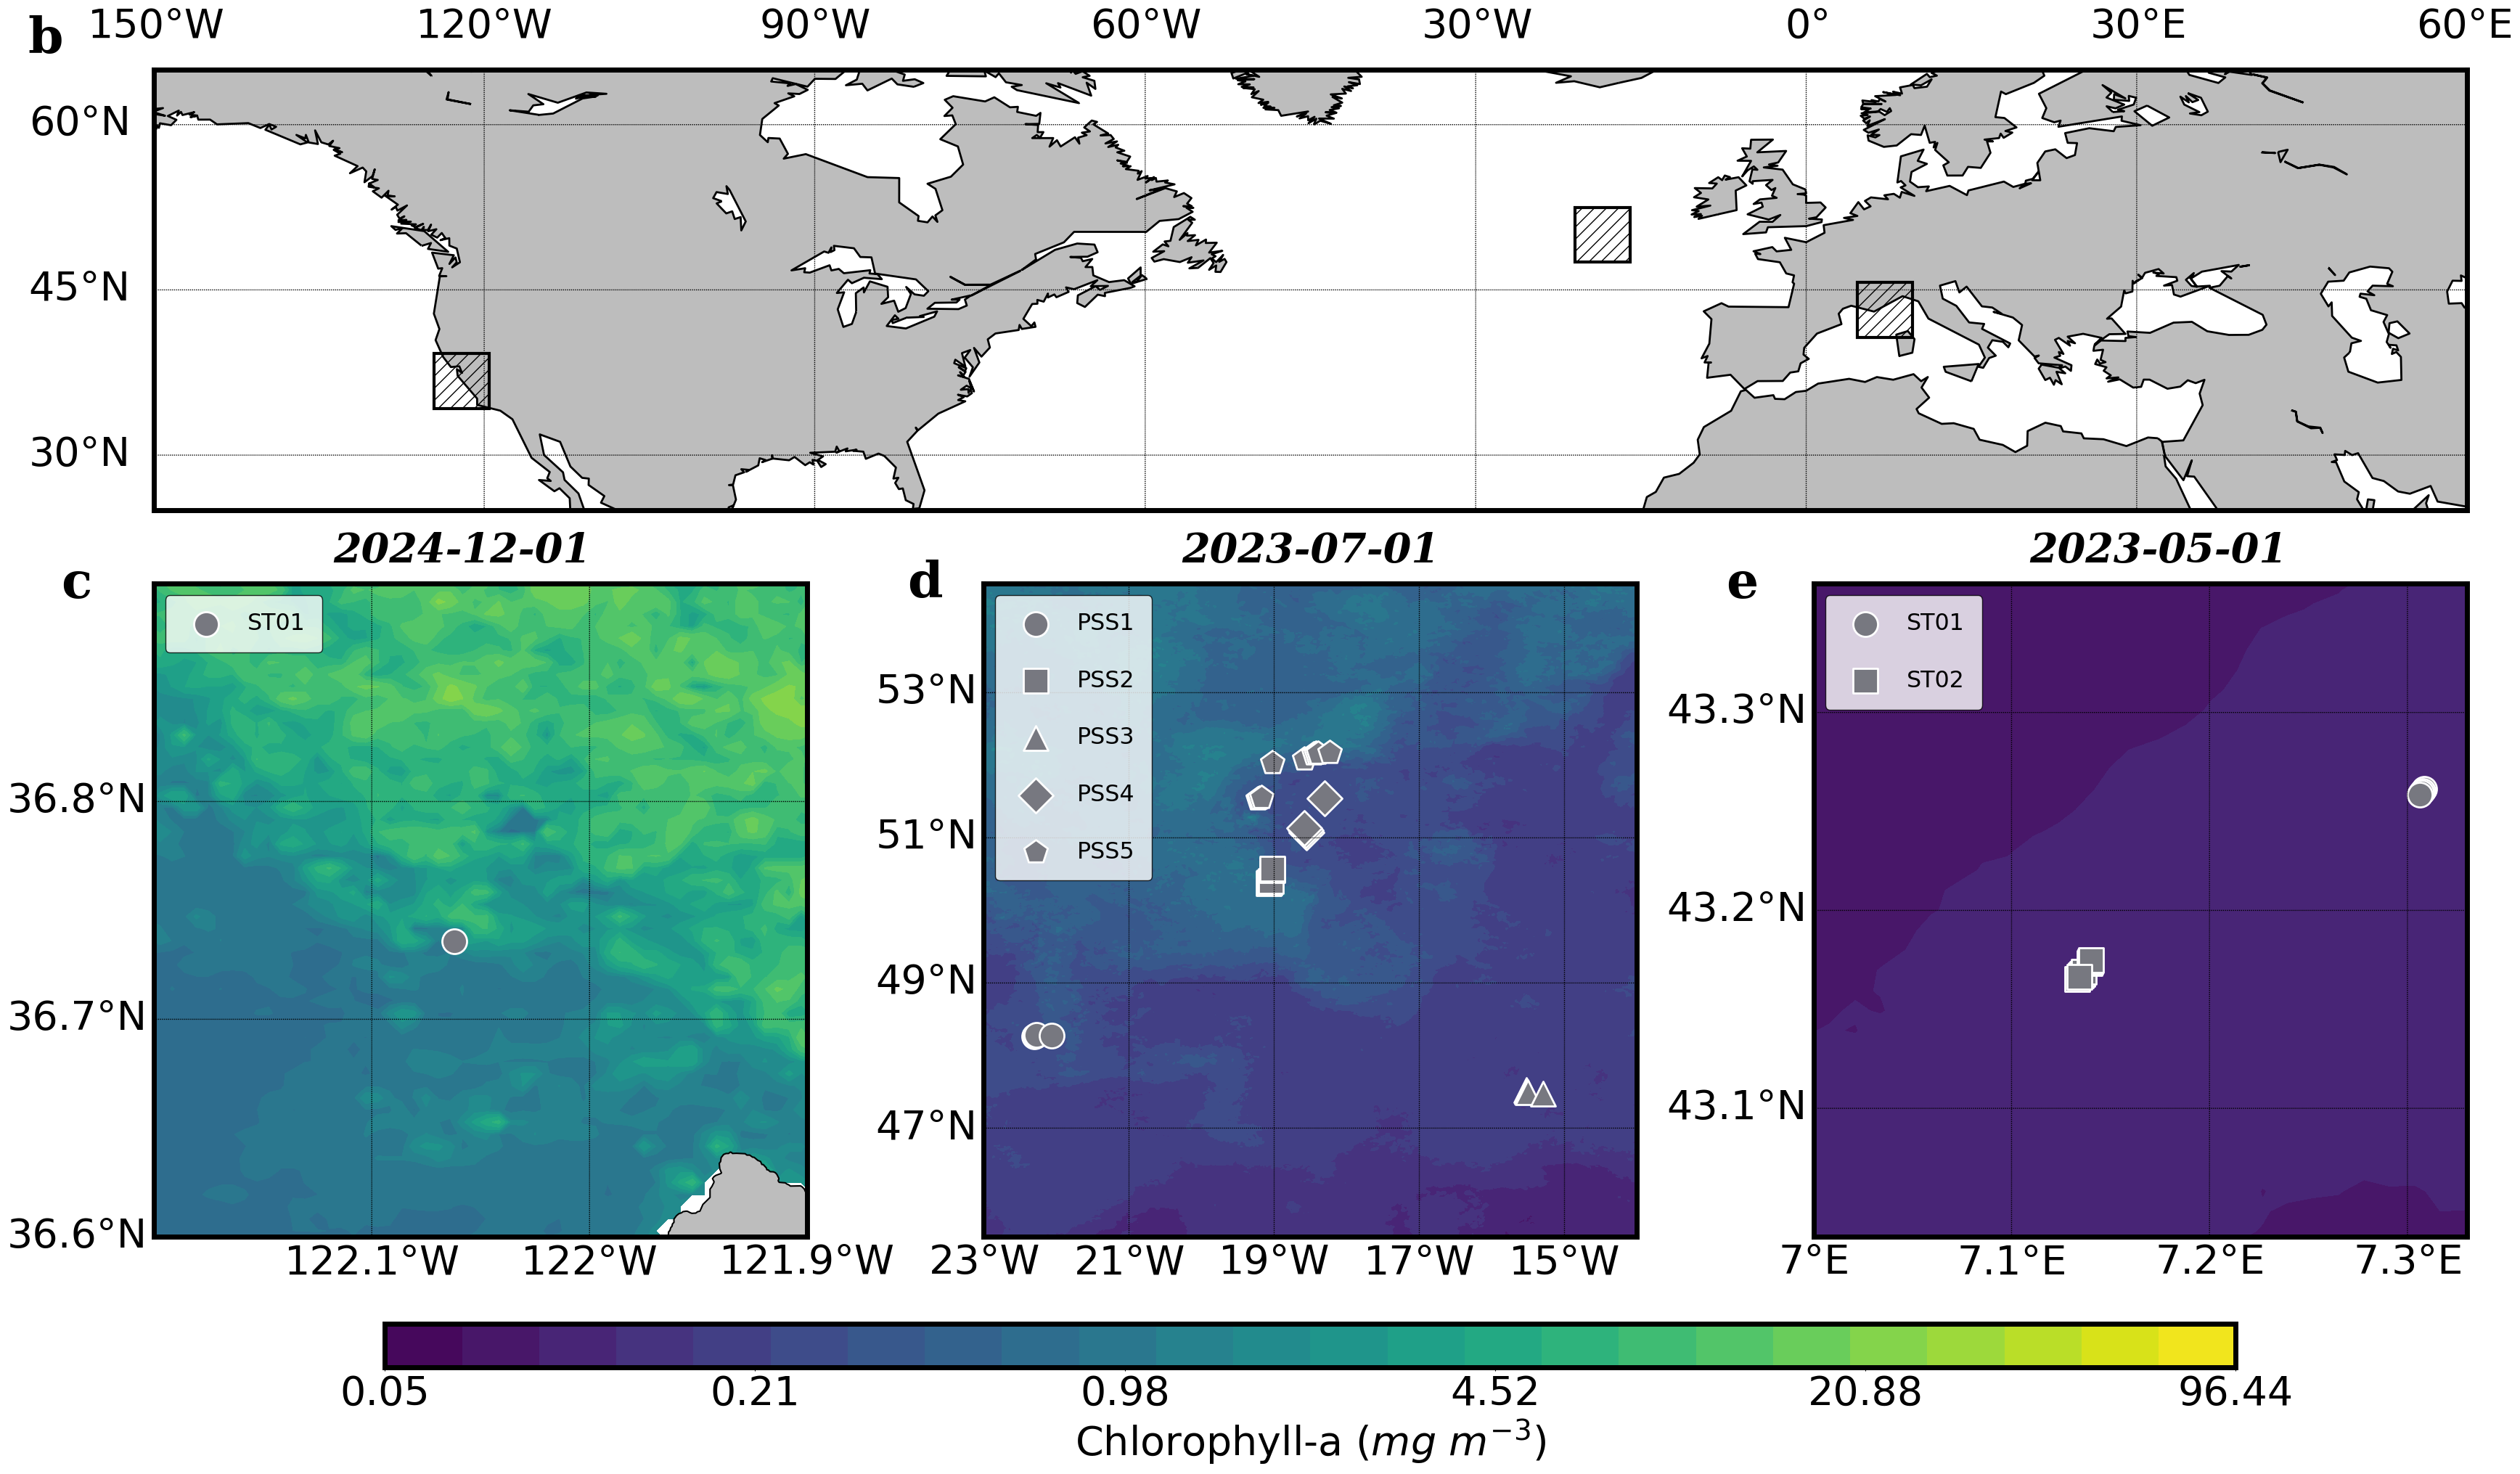

In [26]:
police_size = 40
resolution = 'l'
fig = plt.figure(figsize=(42.5, 30))
ax_world = fig.add_axes([0.125,0.2,0.75,0.77])

# Define world map 
m = Basemap(llcrnrlon=-150, llcrnrlat=25, urcrnrlon=60, urcrnrlat=65,
            projection='cyl', resolution='c', ax=ax_world)
#m.bluemarble()
# Draw map features
m.drawmapboundary(fill_color='white') #'#413F81'
m.drawcoastlines(linewidth=2)
m.fillcontinents(color='#bdbdbd', lake_color='white') #'#413F81'
m.drawparallels(range(-90, 91, 15), labels=[1, 0, 0, 0], linewidth=1, fontsize=police_size)
m.drawmeridians(range(-180, 181, 30), labels=[0, 0, 1, 0], linewidth=1, fontsize=police_size)

# Define the three regions
regions = {
    'MBARI': {'mean_lon': -122.05, 'mean_lat': 36.75, 'color': '#e41a1c'},
    'APERO': {'mean_lon': -18.5, 'mean_lat': 50.0, 'color': '#10698D'},
    'VLFR': {'mean_lon': 7.165, 'mean_lat': 43.2, 'color': '#FFC000'}#FFC000
}

# Define the top center of each subplot (destination for the lines)
subplot_corners = {
    'MBARI': {'x_left': 0.08, 'x_right': 0.38, 'y': 0.6},   # MBARI subplot top-left and top-right
    'APERO': {'x_left': 0.35, 'x_right': 0.65, 'y': 0.6},   # APERO subplot top-left and top-right
    'VLFR': {'x_left': 0.62, 'x_right': 0.92, 'y': 0.6}     # VLFR subplot top-left and top-right
}

square_size = 5  # degrees

# Add colored squares for each region
for region, coords in regions.items():
    x1, y1 = coords['mean_lon'] - square_size / 2, coords['mean_lat'] - square_size / 2
    x2, y2 = coords['mean_lon'] + square_size / 2, coords['mean_lat'] - square_size / 2
    rect = patches.Rectangle(
        (x1, y1), square_size, square_size, linewidth=3, 
        edgecolor='black', facecolor='none', alpha=1, hatch ='//', linestyle ='-'
    )
    ax_world.add_patch(rect)
    
    # Convert map coordinates to figure coordinates
    '''
    x1_fig, y1_fig = ax_world.transData.transform((x1, y1))
    x2_fig, y2_fig = ax_world.transData.transform((x2, y2))
    
    # Destination points (top-left and top-right of subplot)
    x_dest_left, y_dest = subplot_corners[region]['x_left'], subplot_corners[region]['y']
    x_dest_right, y_dest = subplot_corners[region]['x_right'], subplot_corners[region]['y']
    
    # Convert to figure coordinates
    x1_fig, y1_fig = fig.transFigure.inverted().transform((x1_fig, y1_fig))
    x2_fig, y2_fig = fig.transFigure.inverted().transform((x2_fig, y2_fig))
    x_dest_left_fig, y_dest_fig = fig.transFigure.inverted().transform(fig.transFigure.transform((x_dest_left, y_dest)))
    x_dest_right_fig, y_dest_fig = fig.transFigure.inverted().transform(fig.transFigure.transform((x_dest_right, y_dest)))

    # Draw the lines
    line1 = lines.Line2D([x1_fig, x_dest_left_fig], [y1_fig, y_dest_fig], transform=fig.transFigure, color=coords['color'], linewidth=3)
    line2 = lines.Line2D([x2_fig, x_dest_right_fig], [y2_fig, y_dest_fig], transform=fig.transFigure, color=coords['color'], linewidth=3)
    
    fig.lines.extend([line1, line2])
    '''
# Define subplot positions
ax_mbari = fig.add_axes([0.081, 0.15, 0.3, 0.3])  # MBARI bottom left ([left, bottom, width, height]) # 0875
ax_apero = fig.add_axes([0.35, 0.15, 0.3, 0.3])  # APERO bottom middle
ax_vlfr = fig.add_axes([0.619, 0.15, 0.3, 0.3])  # VLFR bottom right

# MBARI
contour_MBARI = plot_map_with_contour(ax=ax_mbari, coord_df=TZEX_positions_MBARI, netcdf_file=ds_MBARI, contour_var='CHL', 
                      min_var=min_chl, max_var=max_chl, n_levels=25, cmap="viridis",
                      llcrnrlon=-122.2, llcrnrlat=36.6, urcrnrlon=-121.9, urcrnrlat=36.9, resolution='f',
                      parallels=np.arange(36, 37.5, 0.1), display_parralel_labels=[True, False, False, False], 
                      meridians=np.arange(-122.5, -121.5, 0.1), display_meridians_labels=[False, False, False, True],
                      police_size=police_size, cbar_label='Chlorophyll-a ($mg$.$m^{-3}$)', loc='upper left', 
                      log_colorbar=True, display_cbar=False)

# APERO
contour_APERO = plot_map_with_contour(ax=ax_apero, coord_df=TZEX_positions_APERO, netcdf_file=ds_APERO, contour_var='CHL', 
                      min_var=min_chl, max_var=max_chl, n_levels=25, cmap="viridis",
                      llcrnrlon=-23, llcrnrlat=47, urcrnrlon=-14, urcrnrlat=53, resolution=resolution,
                      parallels=np.arange(45, 54., 2.), display_parralel_labels=[True, False, False, False], 
                      meridians=np.arange(-23., 8., 2.), display_meridians_labels=[False, False, False, True],
                      police_size=police_size, cbar_label='Chlorophyll-a ($mg$.$m^{-3}$)', loc='upper left', 
                      log_colorbar=True, display_cbar=False)

# VLFR
contour_VLFR = plot_map_with_contour(ax=ax_vlfr, coord_df=TZEX_positions_vlfr, netcdf_file=ds_VLFR, contour_var='CHL', 
                      min_var=min_chl, max_var=max_chl, n_levels=25, cmap="viridis",
                      llcrnrlon=7, llcrnrlat=43.1, urcrnrlon=7.33, urcrnrlat=43.3, resolution=resolution,
                      parallels=np.arange(43, 44., 0.1), display_parralel_labels=[True, False, False, False], 
                      meridians=np.arange(7., 8., 0.1), display_meridians_labels=[False, False, False, True],
                      police_size=police_size, cbar_label='Chlorophyll-a ($mg$.$m^{-3}$)', loc='upper left', 
                      log_colorbar=True, display_cbar=False)


# Increase maps edge line width
for ax in [ax_world, ax_mbari, ax_apero, ax_vlfr]:
    for spine in ax.spines.values():
        spine.set_linewidth(5)  # Adjust thickness
        spine.set_edgecolor("black")
        
# Create a single colorbar for all subplots
cbar_ax = fig.add_axes([0.2, 0.09, 0.6, 0.02])  # Positioning the colorbar horizontally
cbar = fig.colorbar(contour_VLFR, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Chlorophyll-a ($mg$ $m^{-3}$)', size=police_size)
cbar.set_ticks(np.logspace(np.log10(min_chl), np.log10(max_chl), num=6))
cbar.set_ticklabels([f"{tick:.2f}" for tick in np.logspace(np.log10(min_chl), np.log10(max_chl), num=6)])
cbar.ax.tick_params(labelsize=police_size)

# Increase colorbar edge line width 
for spine in cbar.ax.spines.values():
    spine.set_linewidth(5)

# Subplot indices 
fig.text(0.09, 0.7, "b", color='black', 
     fontsize=50, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
     alpha = 1)

fig.text(0.1, 0.45, "c", color='black', 
     fontsize=50, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
     alpha = 1)

fig.text(0.375, 0.45, "d", color='black', 
     fontsize=50, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
     alpha = 1)

fig.text(0.64, 0.45, "e", color='black', 
     fontsize=50, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
     alpha = 1)

# Add the date of each chlorophyll-a shapshot 
#APERO: 2023-07-01
#VLFR: 2023-05-01
#MBARI: 2024-12-01

fig.text(0.225, 0.465, "2024-12-01", color='black', 
     fontsize=40, ha='center', va='center', fontstyle='italic', fontfamily = 'serif', fontweight='bold',
     alpha = 1)

fig.text(0.5, 0.465, "2023-07-01", color='black', 
     fontsize=40, ha='center', va='center', fontstyle='italic', fontfamily = 'serif', fontweight='bold',
     alpha = 1)

fig.text(0.775, 0.465, "2023-05-01", color='black', 
     fontsize=40, ha='center', va='center', fontstyle='italic', fontfamily = 'serif', fontweight='bold',
     alpha = 1)

'''
# Add straight lines to create the zoom-in effect
# MBARI
start_x = 0.17
start_y = 0.6

end_x = 0.2
end_y = 0.46

fig.lines.append(lines.Line2D([start_x, end_x], [start_y, end_y], transform=fig.transFigure, color='#e41a1c', linewidth=5))

# APERO
fig.lines.append(lines.Line2D([0.48, 0.5], [0.6, 0.46], transform=fig.transFigure, color='#10698D', linewidth=5))

# VLFR
fig.lines.append(lines.Line2D([0.79, 0.775], [0.6, 0.46], transform=fig.transFigure, color='#FFC000', linewidth=5))

print('MBARI limits: ')
print('lon: ', ax_mbari.get_xlim()[0], '-', ax_mbari.get_xlim()[1])
print('lat: ', ax_mbari.get_ylim()[0], '-', ax_mbari.get_ylim()[1])
print('---------------')
print('APERO limits: ')
print('lon: ', ax_apero.get_xlim()[0], '-', ax_apero.get_xlim()[1])
print('lat: ', ax_apero.get_ylim()[0], '-', ax_apero.get_ylim()[1])
print('---------------')
print('VLFR limits: ')
print('lon: ', ax_vlfr.get_xlim()[0], '-', ax_vlfr.get_xlim()[1])
print('lat: ', ax_vlfr.get_ylim()[0], '-', ax_vlfr.get_ylim()[1])
'''

# Save the figure
plt.savefig('/home/aaccardo/these_alex/Papers/Rising_stars/Figure_1/Figure_1.png', dpi = 300, bbox_inches='tight')
plt.show()